# 부산광역시 쓰레기 배출량 예측 pt.8

### : unlogged 종속변수로 가장 높은 R2를 위한 종속변수의 조합 찾기 +  예측 및 취약지역 선정까지

<br>

## 00. 기본 설정 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [3]:
# 글씨 선명하게 출력하는 설정

from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

<Axes: title={'center': '한글타이틀'}>

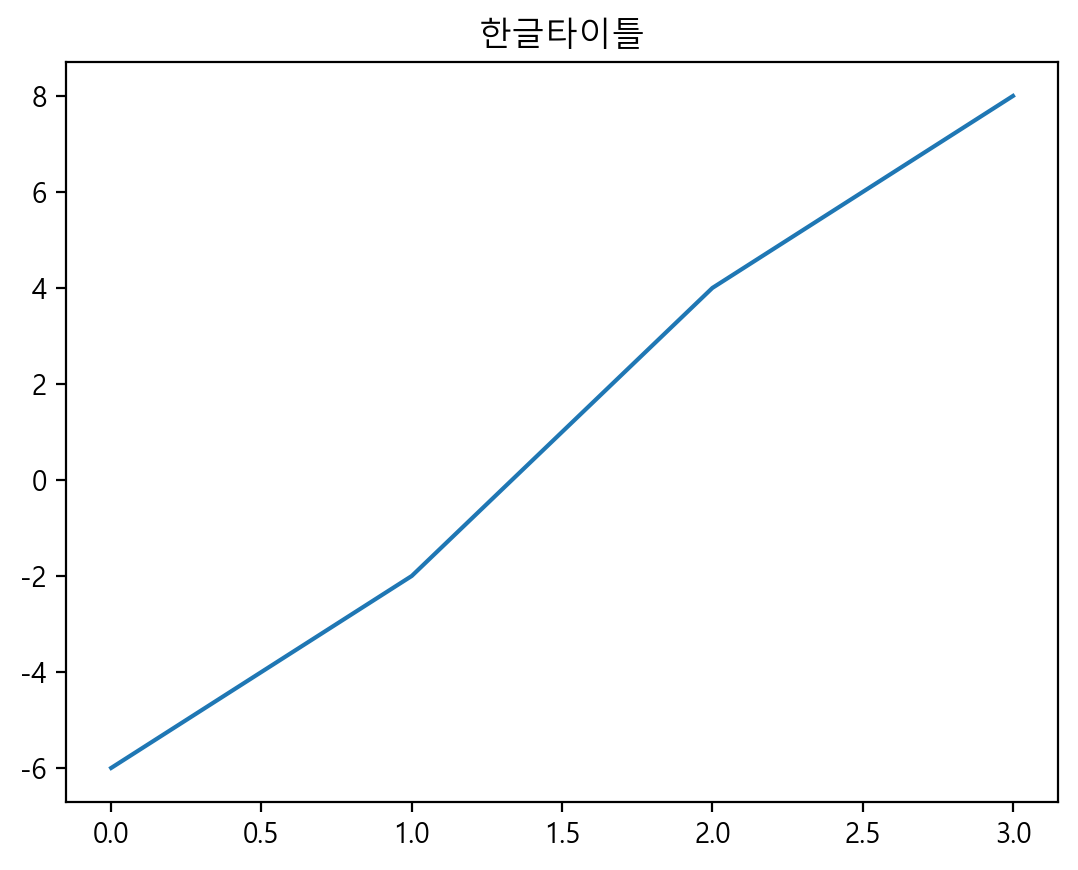

In [4]:
# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-6, -2, 4, 8]).plot(title="한글타이틀")

<br><br>

---
## 01. 데이터 불러오기

In [13]:
df = pd.read_csv("data/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


### 사용하지 않을 '연도' 변수 생성하고 `연도_` col 삭제

In [15]:
year_columns = ['연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

# 연도 변수 생성
df['연도'] = df[year_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)

# 기존 더미 변수 삭제
df = df.drop(columns=year_columns + ['log_혼합배출_후_재활용량'])
df.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022


<br><br>

---
## 02. RandomForest 모델 test
- 로그 변환한 y값(종속변수) `혼합배출_후_재활용량` 쓰고
- 독립변수는 로그변환하지 않은 값을 사용할 거임

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from itertools import combinations

<br>

### 02-1. 임의로 선택한 변수들로 조합해서 가장 높은 R2값 만들기

In [17]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = data['혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최고 R2 ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['R2'].idxmax()])
    
    return results_df_sorted

In [18]:
def plot_model_performance_and_importance(results_df: pd.DataFrame):
    if results_df.empty:
        print("시각화를 할 수 없음. 데이터프레임이 없다..!")
        return

    # num_feature별로 가장 높은 R2값 정렬
    plot_data = results_df.loc[results_df.groupby('num_features')['R2'].idxmax()].reset_index(drop=True)

    # feature의 수에 상관없이 R2가 가장 높은 건 데이터프레임의 0번째 행에 있음
    best_model_row = results_df.iloc[0]
    best_r2_score = best_model_row['R2']
    best_features_combo = best_model_row['selected_features']
    best_importances = best_model_row['feature_importances']
    best_num_features = best_model_row['num_features']

    # 베스트 모델의 feature importance 데이터프레임 만들기
    best_importance_df = pd.DataFrame({
        'feature': best_features_combo,
        'importance': best_importances
    }).sort_values(by='importance', ascending=False)

    # 그래프의 크기 설정
    height_ratio_plot1 = 1.0
    height_ratio_plot2 = max(0.5, len(best_features_combo) * 0.1)

    base_figure_height = 8 
    total_figure_height_ratio = height_ratio_plot1 + height_ratio_plot2
    calculated_height = base_figure_height * (total_figure_height_ratio / 1.5)

    fig, axes = plt.subplots(2, 1, figsize=(10, calculated_height),
                             gridspec_kw={'height_ratios': [height_ratio_plot1, height_ratio_plot2]})
    fig.suptitle('모델 성능 및 피처 중요도 분석', fontsize=16, y=1.02)

    # --- Plot 1: feature의 개수에 따른 R2와 MSE ---
    ax1 = axes[0]
    ax1_2 = ax1.twinx()

    sns.lineplot(x='num_features', y='R2', data=plot_data, marker='o', color='green', ax=ax1)
    sns.lineplot(x='num_features', y='MSE', data=plot_data, marker='s', color='orange', ax=ax1_2)

    ax1.set_xlabel("Number of Features")
    ax1.set_ylabel("R2 Score", color='green')
    ax1_2.set_ylabel("Mean Squared Error (MSE)", color='orange')
    ax1.tick_params(axis='y', labelcolor='green')
    ax1_2.tick_params(axis='y', labelcolor='orange')
    ax1.set_title("R2 Score and MSE by Number of Features")
    ax1.grid(True, linestyle='--', alpha=0.3)

    lines = [
        plt.Line2D([0], [0], color='green', marker='o', label='R2 Score'),
        plt.Line2D([0], [0], color='orange', marker='s', label='MSE')
    ]
    ax1.legend(handles=lines, loc='upper right')

    # --- Plot 2: 베스트 모델의 Feature Importance ---
    ax3 = axes[1]
    sns.barplot(data=best_importance_df, x='importance', y='feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Feature Importance for Best Model (Top {best_num_features} Features, R²={best_r2_score:.4f})')
    ax3.set_xlabel('Importance')
    ax3.set_ylabel('Feature')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])

### 우선 data split
- 19-22년 데이터로 train-valid
- 23년 데이터로 test를 하겠음

In [25]:
# 23년 데이터 만들기
df_test_2023 = df[df['연도'] == 2023].copy().reset_index(drop=True)

# 그 외 데이터 (2023년 부산 제외) → 훈련/검증용
df_modeling = df[~(df['연도'] == 2023)].copy().reset_index(drop=True)

print(f"23년 부산 데이터프레임 shape: {df_test_2023.shape}")
print(f"train-validation용 데이터프레임 shape: {df_modeling.shape}")

23년 부산 데이터프레임 shape: (130, 20)
train-validation용 데이터프레임 shape: (460, 20)


<br>

---
### test 1)

In [27]:
# feature 리스트 정의
my_selected_features_set1 = [
    '총인구수', '주민등록세대수', '아파트비율', '1인가구_비율', '순이동', '총전입'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=6
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 6개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 20/20 완료 - R2: 0.2048, MSE: 40534541.9273

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 15/15 완료 - R2: 0.3413, MSE: 33575866.2280

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 6/6 완료 - R2: 0.3160, MSE: 34866129.0500

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.3501, MSE: 33130508.2341

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                          selected_features        R2  \
6              3                         [총인구수, 아파트비율, 총전입]  0.442208   
21             4                [총인구수, 주민등록세대수, 아파트비율, 순이동]  0.446012   
37             5           [총인구수, 주민등록세대수, 아파트비율, 순이동, 총전입]  0.435820   
41             6  [총인구수, 주민등록세대수, 아파트비율, 1인가구_비율, 순이동, 총전입]  0.350079   

             MSE                                feature_importances  
6   2.843410e+07  [0.44876921073447296, 0.31903260551350554, 0.2...  
21  2.824023e+07  [0.20552802670489734, 0.3402933095572628, 0.29...  
37  2.875975e+07  [0.1864011857274622, 0.28988

,num_features,selected_features,R2,MSE,feature_importances
0,4,"[총인구수, 주민등록세대수, 아파트비율, 순이동]",0.446012,2.824023e+07,"[0.20552802670489734, 0.3402933095572628, 0.29..."
1,3,"[총인구수, 아파트비율, 총전입]",0.442208,2.843410e+07,"[0.44876921073447296, 0.31903260551350554, 0.2..."
2,5,"[총인구수, 주민등록세대수, 아파트비율, 순이동, 총전입]",0.435820,2.875975e+07,"[0.1864011857274622, 0.28988120592549044, 0.27..."


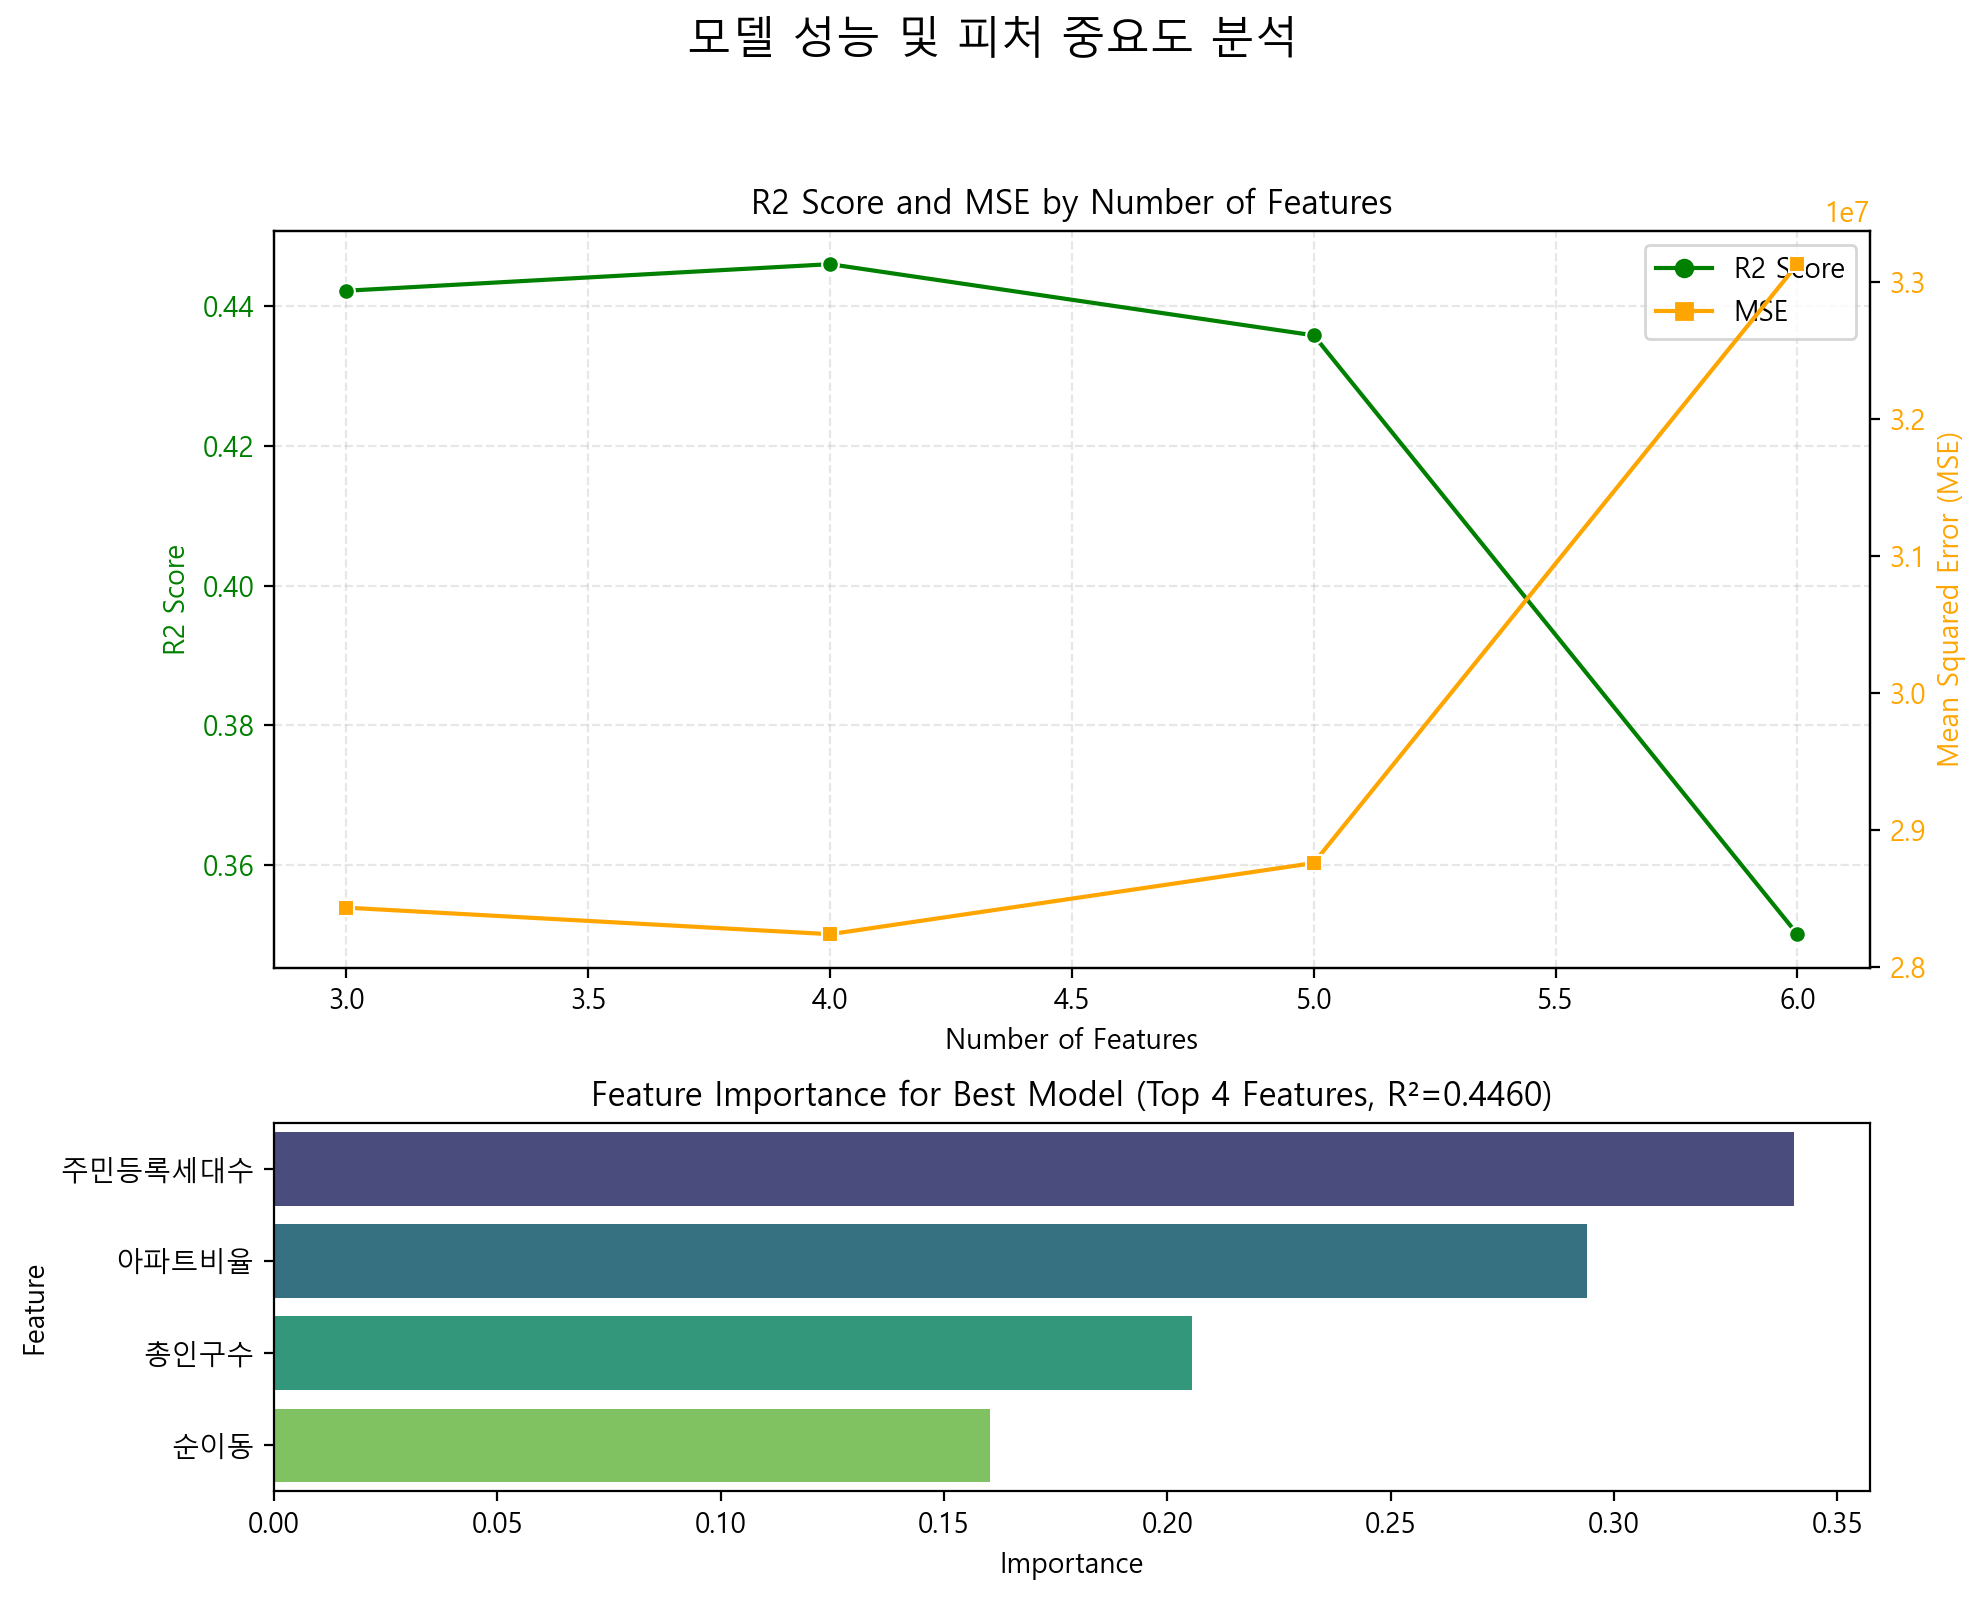

In [28]:
plot_model_performance_and_importance(results_set1)

<br>

---
### test 2) 단순 조합

In [29]:
my_selected_features_set2 = [
    '총인구수', '아파트비율', '단독주택비율', '5인이상가구_비율', '1인가구_비율'
]

# 함수 호출 및 결과 저장
results_set2 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set2,
    min_features=3,
    max_features=5
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set2.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 5개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.1145, MSE: 45139739.7342

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.0238, MSE: 49764384.4251

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.2791, MSE: 36749319.3366

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                          selected_features        R2  \
7              3                   [아파트비율, 단독주택비율, 1인가구_비율]  0.392813   
10             4           [총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율]  0.361152   
15             5  [총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율, 1인가구_비율]  0.279089   

             MSE                                feature_importances  
7   3.095212e+07  [0.42857014521683123, 0.33695015710597326, 0.2...  
10  3.256603e+07  [0.39929385555592545, 0.24004765638720546, 0.2...  
15  3.674932e+07  [0.37779415504305824, 0.1939068703714899, 0.19...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,3,"[아파트비율, 단독주택비율, 1인가구_비율]",0.392813,3.095212e+07,"[0.42857014521683123, 0.33695015710597326, 0.2..."
1,4,"[총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율]",0.361152,3.256603e+07,"[0.39929385555592545, 0.24004765638720546, 0.2..."
2,3,"[총인구수, 아파트비율, 단독주택비율]",0.361145,3.256642e+07,"[0.42744130584436946, 0.2887528745767067, 0.28..."


- 지금까지는 **`[총인구수, 주민등록세대수, 아파트비율, 순이동] (R2: 0.446012)`** 가 가장 높음

<br>

---
### test 3) 인구 + 주거유형

In [30]:
my_selected_features_set3 = [
    '총전입', '아파트비율', '다세대주택비율', '1인가구_비율', '총인구수'
]

# 함수 호출 및 결과 저장
results_set3 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set3,
    min_features=3,
    max_features=5
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set3.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 5개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.3368, MSE: 33808413.9514

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.2870, MSE: 36346710.9119

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.3144, MSE: 34948764.0075

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                     selected_features        R2  \
2              3                    [총전입, 아파트비율, 총인구수]  0.436092   
11             4           [총전입, 아파트비율, 다세대주택비율, 총인구수]  0.387009   
15             5  [총전입, 아파트비율, 다세대주택비율, 1인가구_비율, 총인구수]  0.314410   

             MSE                                feature_importances  
2   2.874587e+07  [0.2275342190764624, 0.3215367252747639, 0.450...  
11  3.124795e+07  [0.13703077521375526, 0.26947121966070564, 0.2...  
15  3.494876e+07  [0.11346938522564254, 0.23284036100710673, 0.1...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,3,"[총전입, 아파트비율, 총인구수]",0.436092,2.874587e+07,"[0.2275342190764624, 0.3215367252747639, 0.450..."
1,3,"[아파트비율, 다세대주택비율, 1인가구_비율]",0.418251,2.965537e+07,"[0.4633165500086218, 0.30836871913272057, 0.22..."
2,4,"[총전입, 아파트비율, 다세대주택비율, 총인구수]",0.387009,3.124795e+07,"[0.13703077521375526, 0.26947121966070564, 0.2..."


<br>

---
### test 5)

In [31]:
my_selected_features_set5 = [
    '총인구수', '아파트비율', '다세대주택비율', '단독주택비율',
    '4인가구_비율', '2인가구_비율', '총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set5 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set5,
    min_features=3,
    max_features=8
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set5.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 8개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: -0.0033, MSE: 51146581.5464

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 70/70 완료 - R2: 0.2698, MSE: 37221759.7829

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.3929, MSE: 30948035.7204

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 28/28 완료 - R2: 0.4550, MSE: 27782053.7621

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 8/8 완료 - R2: 0.4668, MSE: 27180157.6759

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.4547, MSE: 27798935.8565

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                                  selected_features  \
22              3                          [아파트비율, 다세대주택비율, 4인가구_비율]   
119             4                       [다세대주택비율, 4인가구_비율, 총전입, 순이동]   
134             5               [총인구수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]   
189             6      [총인구수, 아파트비율, 다세대주택비율, 4인가구_비율, 2인가구_비율, 순이동]   
214             7  [총인구수, 아파트비율, 다세대주택비율, 4인가구_비율, 2인가구_비율, 총전입, ...   
218             8  [총인구수, 아파트비율, 다세대주택비

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]",0.492998,2.584504e+07,"[0.318957124060795, 0.1877638562954809, 0.1388..."
1,7,"[총인구수, 아파트비율, 다세대주택비율, 4인가구_비율, 2인가구_비율, 총전입, ...",0.488083,2.609561e+07,"[0.28962281805259465, 0.13319967871547078, 0.1..."
2,6,"[총인구수, 아파트비율, 다세대주택비율, 4인가구_비율, 2인가구_비율, 순이동]",0.486973,2.615217e+07,"[0.3098926510713664, 0.1374119386102538, 0.120..."


### updateeeee)
- feature가 `[총인구수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]`일 때 **`R2 = 0.493`** 으로 가장 높음

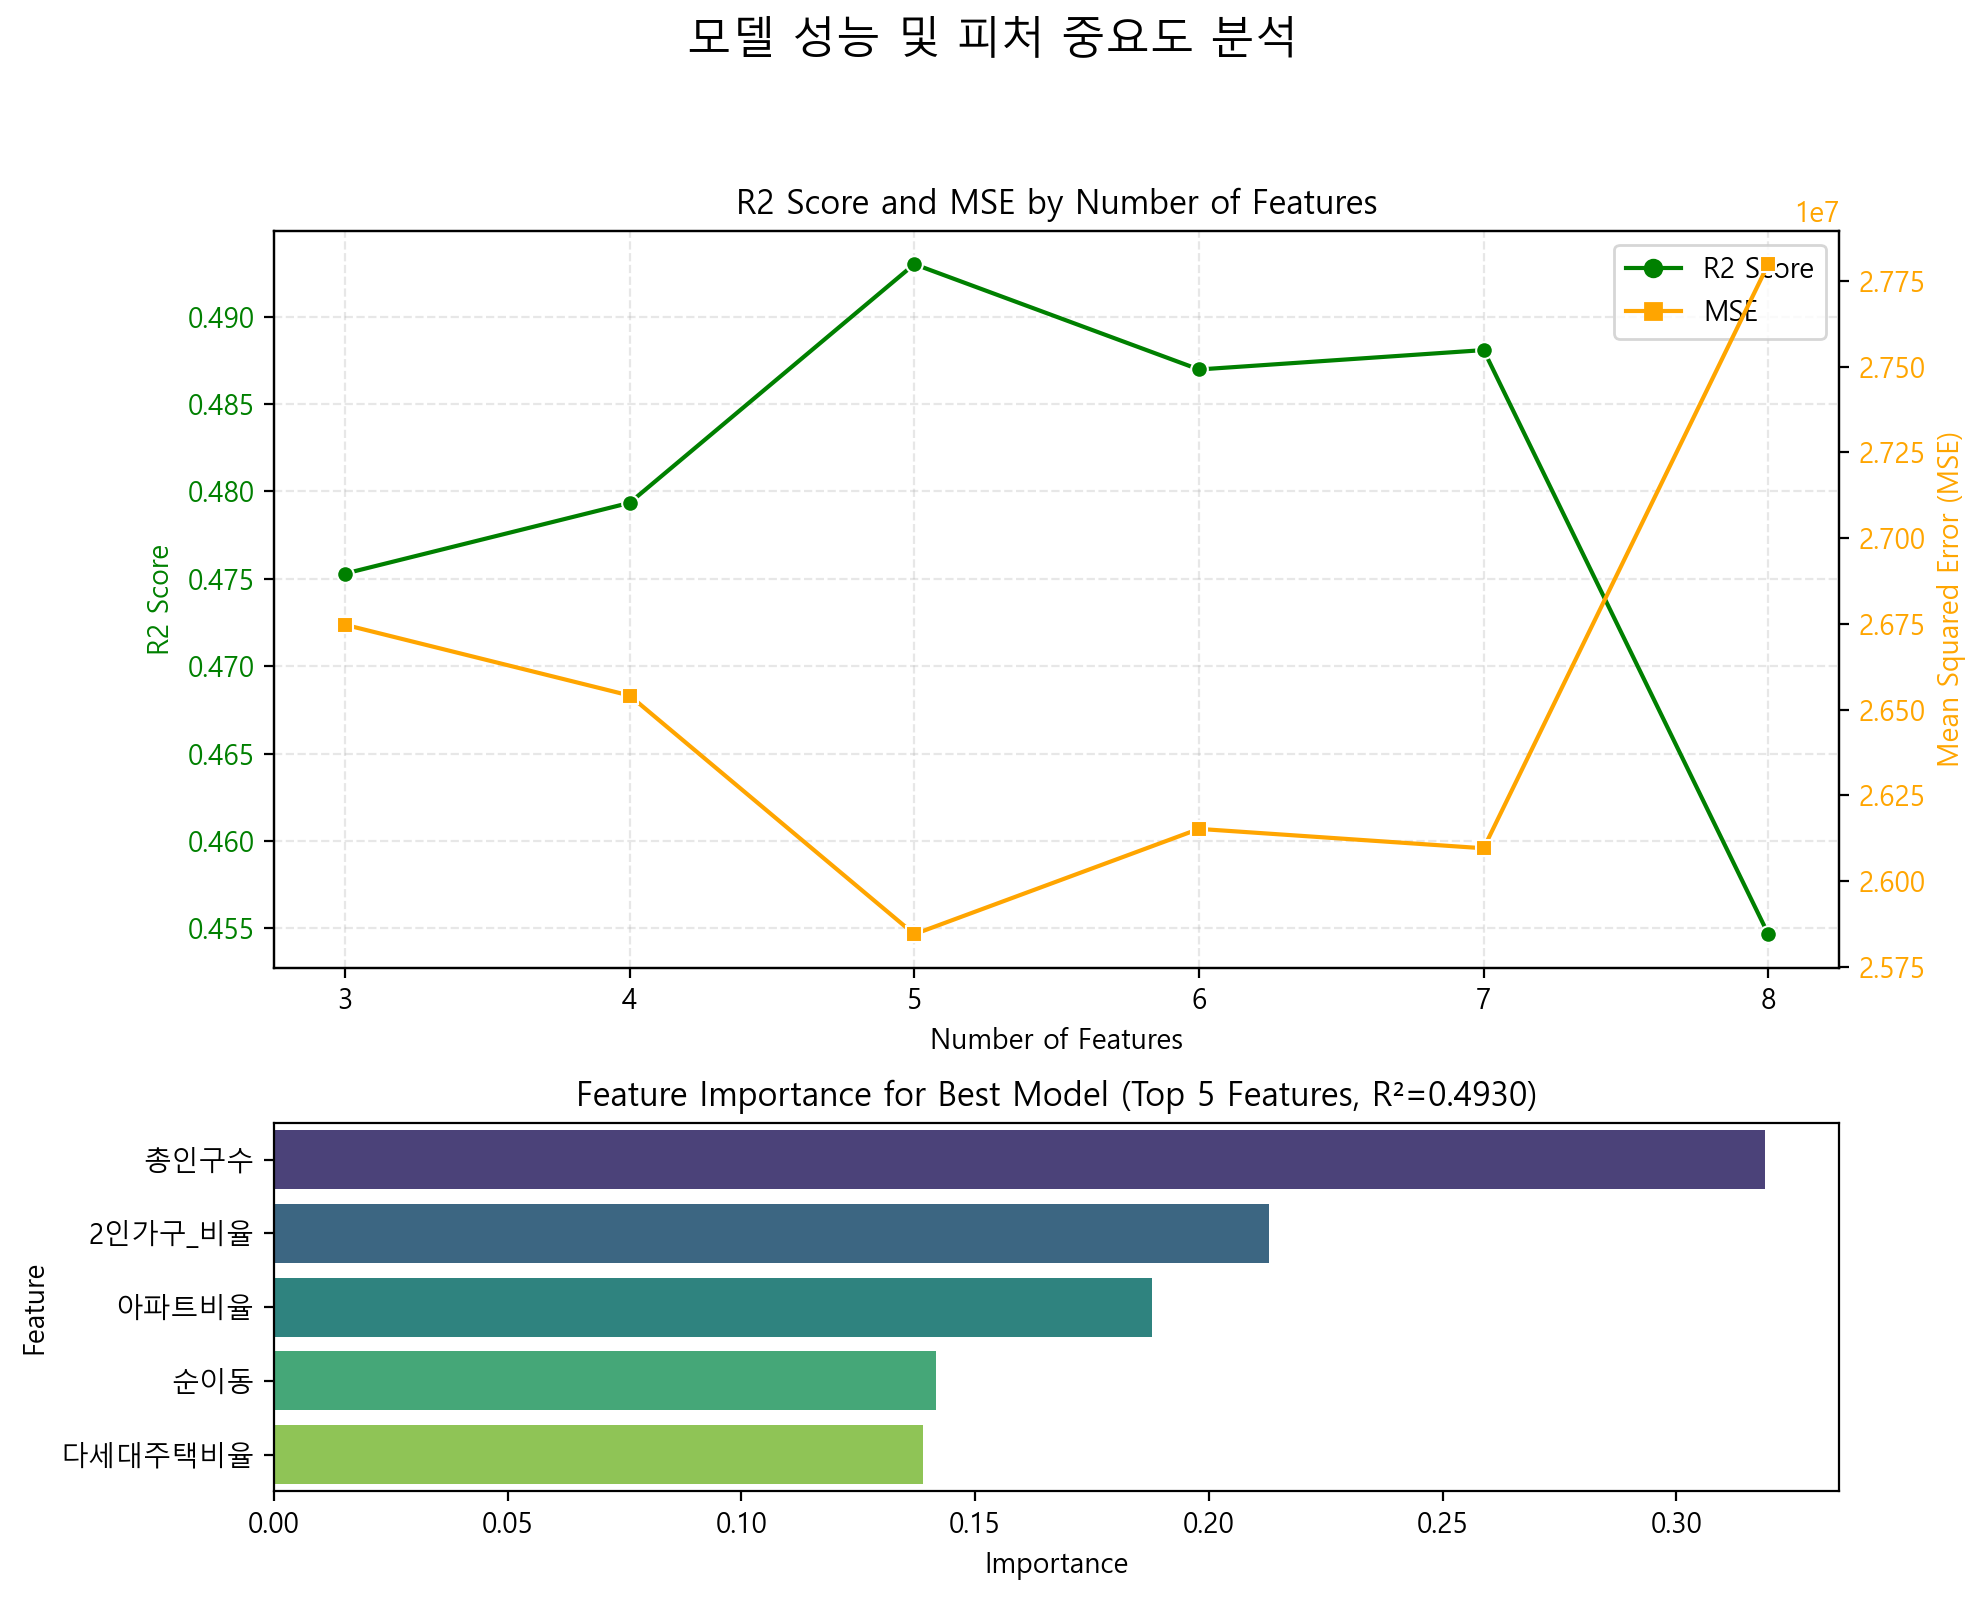

In [32]:
plot_model_performance_and_importance(results_set5)

<br>

### test 6)
- 지금까지 가장 높았던 변수 조합에서 '총인구수'를 '주민등록세대수'로 바꿔서 테스트

In [33]:
my_selected_features_set6 = [
    '주민등록세대수', '아파트비율', '다세대주택비율', '2인가구_비율', '순이동'
]

# 함수 호출 및 결과 저장
results_set6 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set6,
    min_features=2,
    max_features=5
    
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set6.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 5개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 2개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.1043, MSE: 45659597.2772

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.2676, MSE: 37337327.7589

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.4389, MSE: 28603325.0276

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.4495, MSE: 28063488.3927

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                        selected_features        R2  \
4              2                         [아파트비율, 다세대주택비율]  0.431623   
12             3                    [주민등록세대수, 아파트비율, 순이동]  0.404292   
21             4           [주민등록세대수, 아파트비율, 다세대주택비율, 순이동]  0.446236   
25             5  [주민등록세대수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]  0.449479   

             MSE                                feature_importances  
4   2.897371e+07          [0.5440204671069835, 0.45597953289301657]  
12  3.036693e+07  [0.48227123648111686, 0.34301562799628793, 0.1...  
21  2.822878e+07  [0.4313429078160757, 0.257837339958209

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[주민등록세대수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]",0.449479,2.806349e+07,"[0.35812814847510377, 0.18715361218910403, 0.1..."
1,4,"[주민등록세대수, 아파트비율, 다세대주택비율, 순이동]",0.446236,2.822878e+07,"[0.4313429078160757, 0.2578373399582095, 0.187..."
2,4,"[아파트비율, 다세대주택비율, 2인가구_비율, 순이동]",0.438889,2.860333e+07,"[0.4008977516825164, 0.17271206382543042, 0.17..."


> - `총인구수`가 `주민등록세대수`보다 좋은 결과를 가져옴

<br>

---
### test 7)

In [36]:
my_selected_features_set7 = [
    '총인구수', '단독주택비율', '아파트비율', '다세대주택비율',
    '3인가구_비율', '순이동', '2인가구_비율'
]

# 함수 호출 및 결과 저장
results_set7 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set7,
    min_features=3,
    max_features=7
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set7.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 7개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.2277, MSE: 39367553.8408

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.3448, MSE: 33400776.7402

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 21/21 완료 - R2: 0.4271, MSE: 29206220.9339

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 7/7 완료 - R2: 0.2049, MSE: 40531567.3660

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.4260, MSE: 29262511.2003

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                                  selected_features        R2  \
15             3                           [단독주택비율, 아파트비율, 다세대주택비율]  0.471936   
55             4                  [단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율]  0.471318   
82             5               [총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율]  0.489041   
96             6      [총인구수, 아파트비율, 다세대주택비율, 3인가구_비율, 순이동, 2인가구_비율]  0.462412   
98             7  [총인구수, 단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율, 순이동, 2...  0.425957   

             MSE                                feature_impo

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율]",0.489041,2.604677e+07,"[0.3175308692001934, 0.18706673365555002, 0.13..."
1,3,"[단독주택비율, 아파트비율, 다세대주택비율]",0.471936,2.691872e+07,"[0.30010823079312354, 0.38529564861918353, 0.3..."
2,4,"[단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율]",0.471318,2.695020e+07,"[0.2265641778257656, 0.31580522545387163, 0.24..."


<br>

### test 8)
- [총인구수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]일때 .49x

In [37]:
my_selected_features_set8 = [
    '총인구수', '단독주택비율', '아파트비율', '다세대주택비율',
    '순이동', '2인가구_비율', '5인이상가구_비율'
]

# 함수 호출 및 결과 저장
results_set8 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set8,
    min_features=3,
    max_features=7
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set8.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 7개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.0188, MSE: 50015350.8785

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.2809, MSE: 36657008.8569

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 21/21 완료 - R2: 0.2667, MSE: 37379663.6114

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 7/7 완료 - R2: 0.1401, MSE: 43834491.6383

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.4453, MSE: 28278198.1413

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                                  selected_features        R2  \
15             3                           [단독주택비율, 아파트비율, 다세대주택비율]  0.471936   
55             4                      [단독주택비율, 아파트비율, 다세대주택비율, 순이동]  0.451715   
80             5               [총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율]  0.489041   
96             6    [총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율, 5인이상가구_비율]  0.473910   
98             7  [총인구수, 단독주택비율, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율, 5...  0.445267   

             MSE                                feature_impo

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율]",0.489041,2.604677e+07,"[0.3175308692001934, 0.18706673365555002, 0.13..."
1,6,"[총인구수, 아파트비율, 다세대주택비율, 순이동, 2인가구_비율, 5인이상가구_비율]",0.473910,2.681808e+07,"[0.3095134370189341, 0.16890149116091036, 0.12..."
2,3,"[단독주택비율, 아파트비율, 다세대주택비율]",0.471936,2.691872e+07,"[0.30010823079312354, 0.38529564861918353, 0.3..."


<br>

---
### test 9)

In [34]:
my_selected_features_set9 = [
    '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
    '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율'
]

# 함수 호출 및 결과 저장
results_set9 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set9,
    min_features=4,
    max_features=8
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set9.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 10개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/210 완료 - R2: -0.1106, MSE: 56613436.8983
  > 조합 200/210 완료 - R2: 0.3403, MSE: 33627618.2966
  > 조합 210/210 완료 - R2: 0.0447, MSE: 48697395.7816

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/252 완료 - R2: 0.3511, MSE: 33079880.7416
  > 조합 200/252 완료 - R2: -0.0284, MSE: 52423208.5604
  > 조합 252/252 완료 - R2: -0.0582, MSE: 53940927.4526

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 100/210 완료 - R2: 0.3472, MSE: 33277190.4222
  > 조합 200/210 완료 - R2: -0.0225, MSE: 52122981.0083
  > 조합 210/210 완료 - R2: 0.3548, MSE: 32890283.1653

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 100/120 완료 - R2: 0.0519, MSE: 48329035.5727
  > 조합 120/120 완료 - R2: 0.3513, MSE: 33066111.9421

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 45/45 완료 - R2: 0.0532, MSE: 48264942.9008

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                                  selected_features  \
92              4                  [단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율]   
358             5         [단독

,num_features,selected_features,R2,MSE,feature_importances
0,4,"[단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율]",0.471318,2.695020e+07,"[0.2265641778257656, 0.31580522545387163, 0.24..."
1,5,"[단독주택비율, 아파트비율, 다세대주택비율, 3인가구_비율, 4인가구_비율]",0.471031,2.696484e+07,"[0.20684033982278396, 0.28597252074380014, 0.2..."
2,4,"[단독주택비율, 아파트비율, 다세대주택비율, 4인가구_비율]",0.469412,2.704738e+07,"[0.2661554639636027, 0.3442629654179745, 0.267..."


<br>

### 02-2. test 결과 정리

> `[총인구수, 아파트비율, 다세대주택비율, 2인가구_비율, 순이동]`일 때 **`R2 = 0.493`** 으로 가장 높음

그리고 로그를 취한 값보다 성능이 **`0.2`** 정도 떨어짐..

<br>

- log값으로 찾은 조합과 R2:
    - [총인구수, 단독주택비율, 연립주택비율, 2인가구_비율, 4인가구_비율]
    - R2: `0.632507`

<br>

---
### 02-3. RandomForest 모델 튜닝
- `[총인구수, 단독주택비율, 2인가구_비율, 4인가구_비율]` 조합으로 하이퍼파라미터 튜닝

In [38]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

In [39]:
selected_features = ['총인구수', '아파트비율', '다세대주택비율', '2인가구_비율', '순이동']
X = df_modeling[selected_features]
y = df_modeling['혼합배출_후_재활용량']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [175, 200, 250, 300],
    'max_depth': [11, 12, 13, 14],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1],
    'max_features': ['sqrt', 0.4, 0.6, 0.8]
}

In [55]:
# 모델 정의 및 그리드서치
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
# 모델 훈련
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [11, 12, 13, 14],
                         'max_features': ['sqrt', 0.4, 0.6, 0.8],
                         'min_samples_leaf': [1], 'min_samples_split': [2, 3],
                         'n_estimators': [175, 200, 250, 300]},
             scoring='r2', verbose=1)

In [56]:
# 테스트 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

# 성능 출력
print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"테스트 세트 R²: {r2_score(y_val, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(y_val, y_pred):.4f}")


최적 파라미터: {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
테스트 세트 R²: 0.4621
테스트 세트 MSE: 27420610.5882


In [ ]:
# history
"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [150, 175, 200, 225, 250],
    'max_depth': [5, 10, 12],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2, 4],
}
최적 파라미터: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 150}
테스트 세트 R²: 0.3488
테스트 세트 MSE: 33195834.6513
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [225, 250, 275],
    'max_depth': [10, 11, 12, 13],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}
최적 파라미터: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 275}
테스트 세트 R²: 0.3510
테스트 세트 MSE: 33082991.8997
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [125, 150, 175, 200],
    'max_depth': [10, 11, 12, 13],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
}
최적 파라미터: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 175}
테스트 세트 R²: 0.4615
테스트 세트 MSE: 27453234.2790
"""

"""
param_grid = {
    'n_estimators': [175, 200, 225],
    'max_depth': [10, 11, 12],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.6]
}
최적 파라미터: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 175}
테스트 세트 R²: 0.4587
테스트 세트 MSE: 27594648.9091
"""

"""
param_grid = {
    'n_estimators': [175, 200, 250, 300],
    'max_depth': [11, 12, 13, 14],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1],
    'max_features': ['sqrt', 0.4, 0.6, 0.8]
}
최적 파라미터: {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
테스트 세트 R²: 0.4621
테스트 세트 MSE: 27420610.5882
"""

<br>

---
### 02-4. 혹시몰라 해보는 XGBoost w/ gridsearch
- `[총인구수, 단독주택비율, 2인가구_비율, 4인가구_비율]` 조합 유지

In [57]:
from xgboost import XGBRegressor

In [58]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [59]:
# 하이퍼파라미터 후보 설정
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=1)

In [60]:
# 모델 성능 평가
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"테스트 세트 R²: {r2_score(y_val, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(y_val, y_pred):.4f}")


최적 파라미터: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
테스트 세트 R²: 0.3861
테스트 세트 MSE: 31293083.5290


<br>

> 하이퍼파라미터 튜닝 && XGBoost 테스트 결과 그냥 기본 랜덤포레스트 모델 쓰는걸로..~ 

<br>

<br>

---
## 03. 최종 모델로 23년과 부산 예측

<br>

### 03-1. R2-mse 계산

In [61]:
# X, y 분리 (훈련용 데이터)
X = df_modeling[selected_features]
y = df_modeling['혼합배출_후_재활용량']

# 훈련-검증 8:2 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# GridSearch를 통해 찾은 가장 높은 성능을 보이는 모델 정의
model = RandomForestRegressor(
    n_estimators=250,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=250, random_state=42)

In [63]:
# 검증 성능 확인
y_val_pred = model.predict(X_val)
r2_val = r2_score(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)

print("[검증 성능]")
print(f"R2 (Validation): {r2_val:.4f}")
print(f"MSE (Validation): {mse_val:.4f}")

[검증 성능]
R2 (Validation): 0.4930
MSE (Validation): 25845041.6078


In [64]:
# 23년 전국 대상 예측
X_test_2023 = df_test_2023[selected_features]
y_test_2023 = df_test_2023['혼합배출_후_재활용량']

In [65]:
# 예측 수행
y_pred_2023 = model.predict(X_test_2023)

df_test_2023['예측값'] = y_pred_2023
df_test_2023['실제값'] = y_test_2023
df_test_2023['오차(실제값기준)'] = df_test_2023['실제값'] - df_test_2023['예측값']

print("[2023년 테스트 성능 평가]")

# 실제 스케일 기준 R2
r2_2023_real = r2_score(df_test_2023['실제값'], df_test_2023['예측값'])
mse_2023_real = mean_squared_error(df_test_2023['실제값'], df_test_2023['예측값'])
print(f"2023년 실제값 기준 R2: {r2_2023_real:.4f}")
print(f"2023년 실제값 기준 MSE: {mse_2023_real:.4f}")

[2023년 테스트 성능 평가]
2023년 실제값 기준 R2: 0.3569
2023년 실제값 기준 MSE: 161045151.8089


In [66]:
# 부산 지역만 확인!
df_busan_2023 = df_test_2023[df_test_2023['시도'] == '부산'].copy().reset_index(drop=True)

# 부산 성능 (실제)
r2_busan_2023_real = r2_score(df_busan_2023['실제값'], df_busan_2023['예측값'])
mse_busan_2023_real = mean_squared_error(df_busan_2023['실제값'], df_busan_2023['예측값'])

print("[2023년 부산 지역 테스트 성능 평가]")
print(f"23년 부산 실제값 기준 R2: {r2_busan_2023_real:.4f}")
print(f"23년 부산 실제값 기준 MSE: {mse_busan_2023_real:.4f}")

[2023년 부산 지역 테스트 성능 평가]
23년 부산 실제값 기준 R2: 0.0101
23년 부산 실제값 기준 MSE: 66242807.6850


In [67]:
print("\n[2023년 부산 예측 오차 상위 5개]")
df_busan_2023[['시군구', '예측값', '실제값', '오차(실제값기준)']].sort_values(by='오차(실제값기준)', ascending=False).head(5)


[2023년 부산 예측 오차 상위 5개]


,시군구,예측값,실제값,오차(실제값기준)
6,부산진구,23715.2608,41448.2,17732.9392
3,남구,10676.6376,23032.7,12356.0624
1,금정구,12509.5740,24013.1,11503.5260
11,수영구,5828.9056,15895.6,10066.6944
12,연제구,10340.3732,18574.9,8234.5268


<br>

---
### 03-2. 예측 오차 시각화
> "실제값이 예측보다 훨씬 높다" >> 예상보다 많은 양이 이중처리/재활용되었고 >> 예측이 어려운 과부하 상황이므로 정책상 취약 구역 후보

<br>

### 1) 순위 확인

In [69]:
# 부산 구별 예측 정확도 순위 (예측 오차가 작은 순서대로 — 절댓값 기준)
df_busan_2023['오차절댓값'] = df_busan_2023['오차(실제값기준)'].abs()
accuracy_ranking = df_busan_2023.sort_values(by='오차절댓값').reset_index(drop=True)

print("\n[시군구별 예측 정확도 순위 — 오차 절댓값 기준]")
accuracy_ranking[['시군구', '예측값', '실제값', '오차(실제값기준)', '오차절댓값']]


[시군구별 예측 정확도 순위 — 오차 절댓값 기준]


,시군구,예측값,실제값,오차(실제값기준),오차절댓값
0,서구,6116.3588,6157.8,41.4412,41.4412
1,강서구,11927.6232,11805.7,-121.9232,121.9232
2,동래구,13478.3940,14674.0,1195.6060,1195.6060
3,사상구,8830.7116,11497.8,2667.0884,2667.0884
4,동구,6648.1200,10200.1,3551.9800,3551.9800
5,기장군,7762.1712,13154.8,5392.6288,5392.6288
6,북구,14238.4232,19735.6,5497.1768,5497.1768
7,중구,7120.5592,13367.1,6246.5408,6246.5408
8,영도구,4232.7080,11404.7,7171.9920,7171.9920
9,사하구,16987.6944,24589.7,7602.0056,7602.0056


<br>

### 2) lineplot

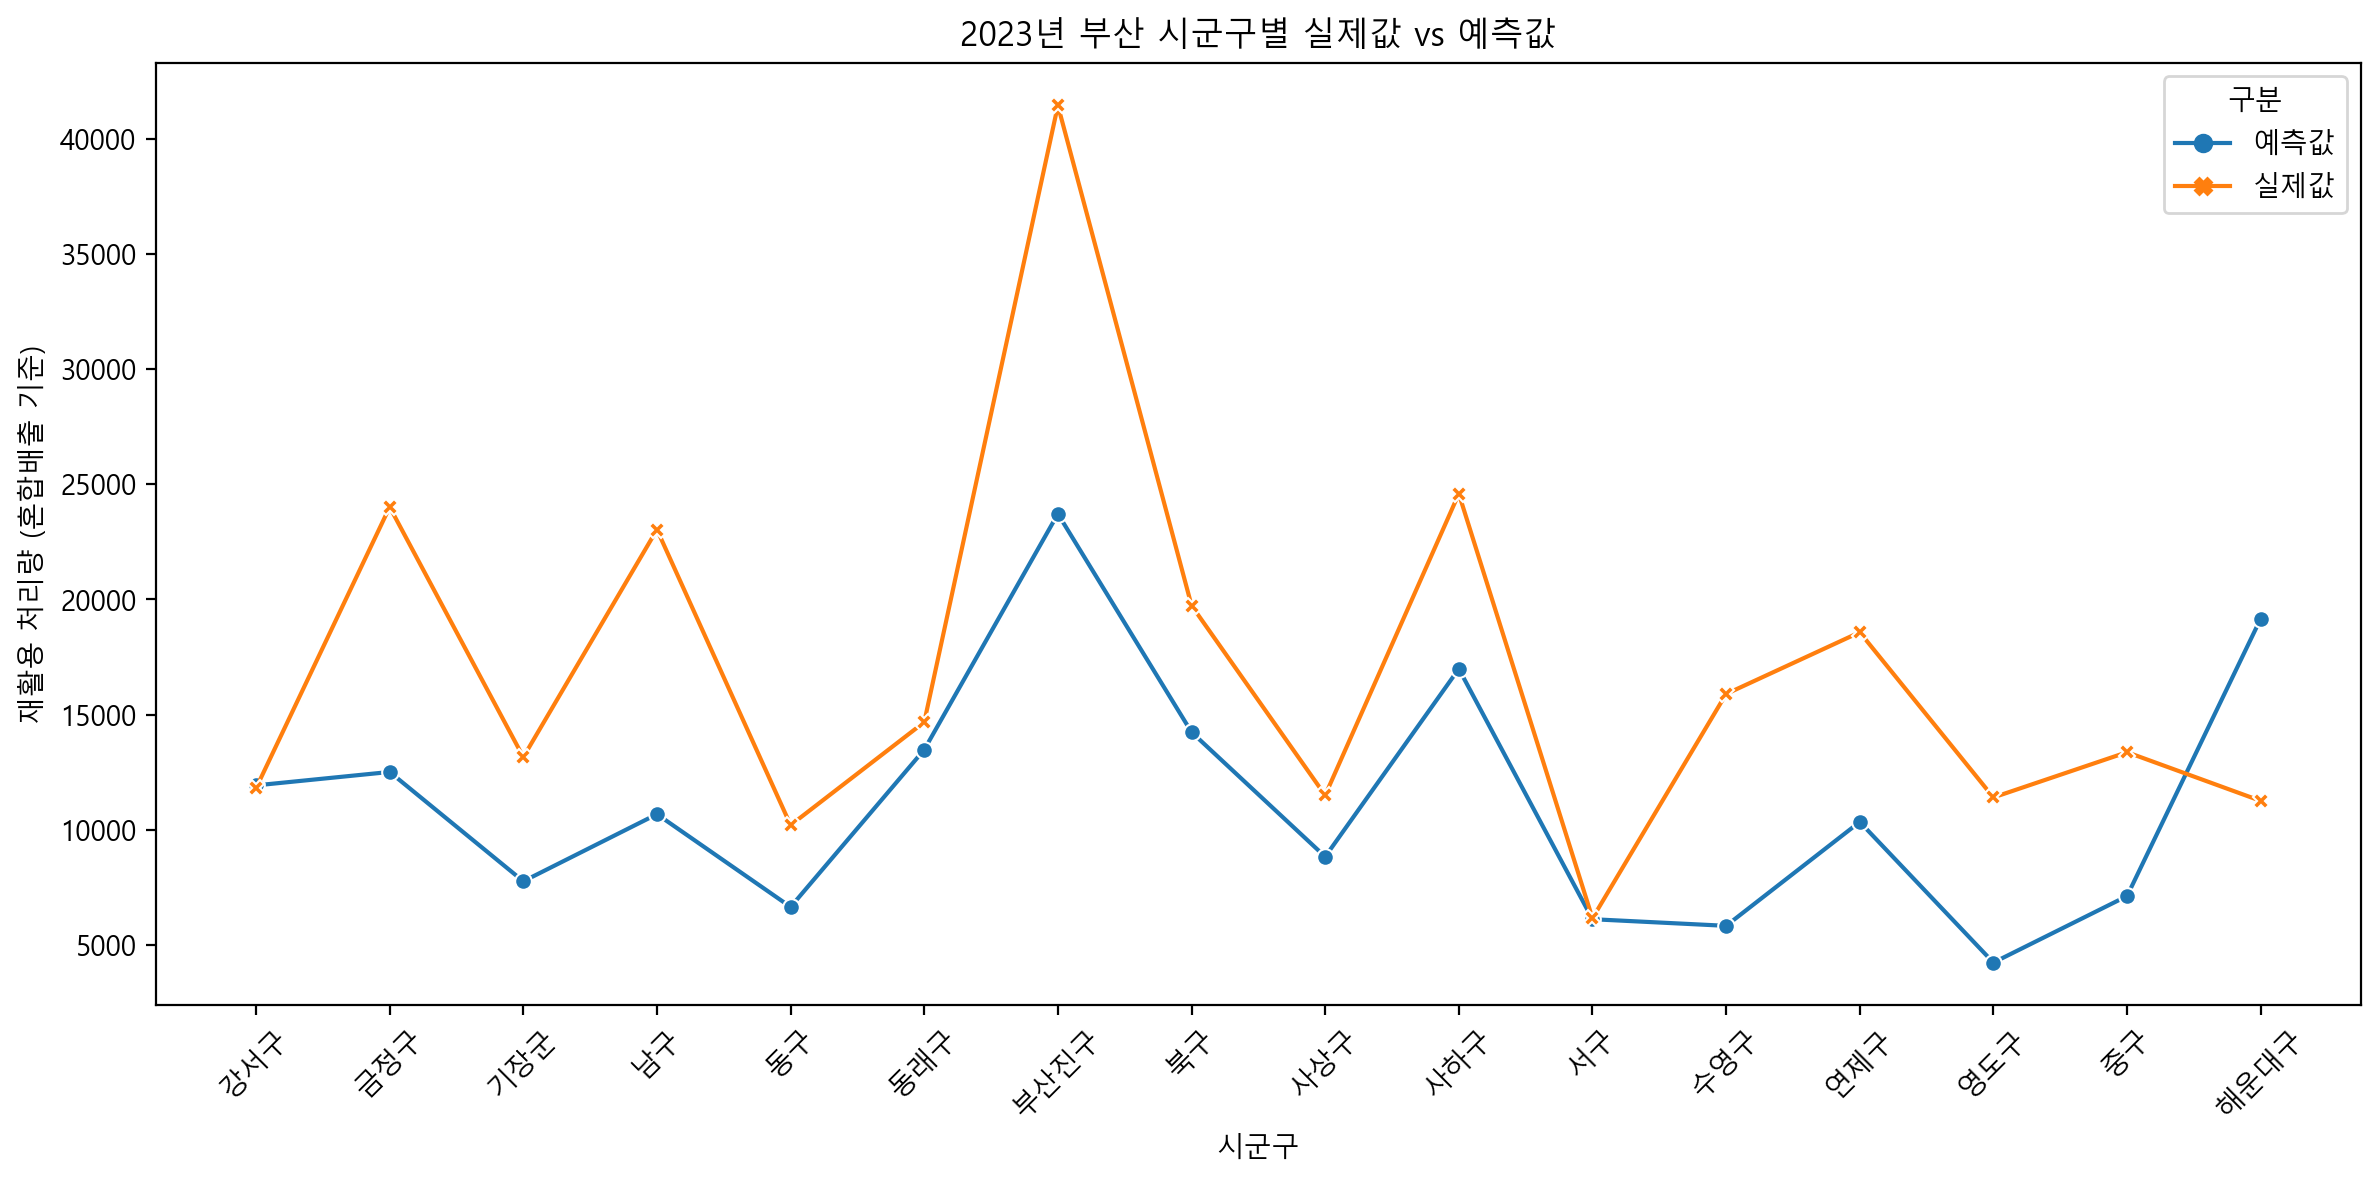

In [71]:
# 시군구별 예측값/실제값 형태 변환
df_plot = df_busan_2023[['시군구', '예측값', '실제값']].melt(id_vars='시군구', var_name='구분', value_name='값')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='시군구', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 실제값 vs 예측값')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('시군구')
plt.tight_layout()
plt.legend(title='구분')

### 2) barplot

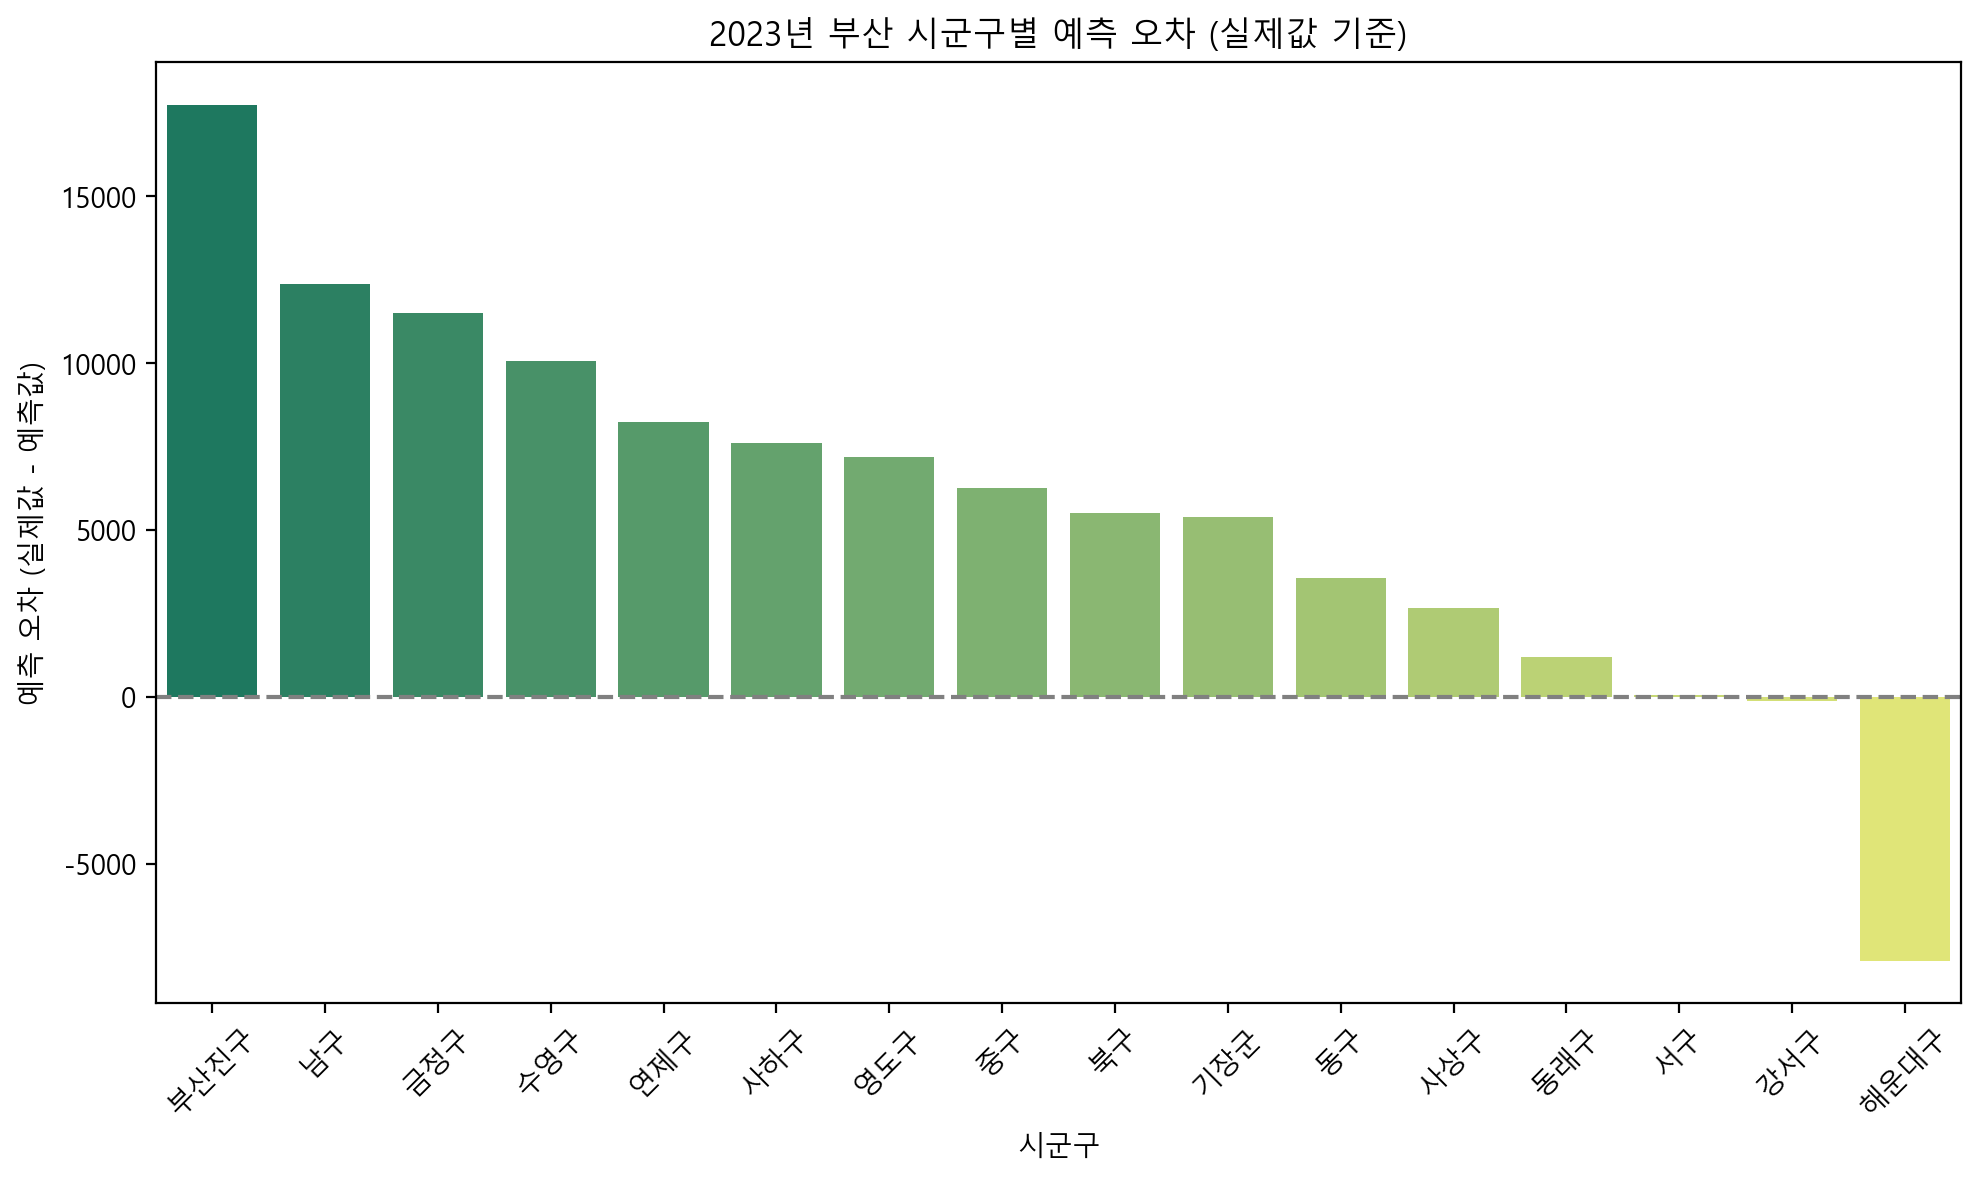

In [73]:
plt.figure(figsize=(10, 6))
df_sorted_heatmap = df_busan_2023.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='시군구', y='오차(실제값기준)', palette='summer')
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()